# Breast Cancer — PQFM híbrido com PCA e busca manual

Mantemos as 569 amostras, seis features clássicas e alvo positivo maligno.
Escolha um dos três PQFMs abaixo. Todos usam simulação ideal, sem credenciais.
O arquivo mantém o nome histórico `xyz_breast_cancer_shap_pipeline.ipynb`, mas este fluxo usa **PCA, não SHAP**.

Em cada fold: StandardScaler → concatenação (clássicas escaladas + quânticas) → PCA de seis componentes → GradientBoosting.
O PCA centraliza a matriz concatenada, sem um segundo escalonamento. Os componentes são projeções, não uma seleção de colunas.
As features são preparadas uma vez por fold e reutilizadas por todas as combinações do classificador.


In [1]:
from __future__ import annotations

from time import perf_counter
from types import SimpleNamespace
from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import ParameterGrid, StratifiedKFold, train_test_split
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
SHOTS = 4096
USE_GPU_STATEVECTOR = True  # Use False para executar em CPU.

from sklearn.datasets import load_breast_cancer

from pqfmlib import CDIsingProjectiveQFM, HeisenbergProjectiveQFM, XYZProjectiveQFM

In [2]:
dataset = load_breast_cancer(as_frame=True)
selected_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness",
    "mean compactness",
]
X = dataset.data.loc[:, selected_features].copy()
y = (dataset.target.to_numpy() == 0).astype(int)  # maligno = classe positiva
n = X.shape[1]
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness
0,17.99,10.38,122.80,1001.0,0.11840,0.27760
1,20.57,17.77,132.90,1326.0,0.08474,0.07864
2,19.69,21.25,130.00,1203.0,0.10960,0.15990
3,11.42,20.38,77.58,386.1,0.14250,0.28390
4,20.29,14.34,135.10,1297.0,0.10030,0.13280


## Escolha do PQFM

Altere `PQFM_OPTION` para `"heisenberg"`, `"xyz"` ou `"cd_ising"` e execute novamente as células seguintes.
Somente o mapa escolhido será executado. GPU é configurável na célula de imports.


In [15]:
PQFM_OPTION = "xyz"

pqfm_options = {
    "heisenberg": HeisenbergProjectiveQFM(
        name_file="breast_cancer_heisenberg_pca", q_enc=7,
        ideal=True, simulation=True, expectation_method="statevector",
        seed=SEED, shots=SHOTS,  # shots é ignorado neste modo.
        use_gpu_statevector=USE_GPU_STATEVECTOR,
    ),
    "xyz": XYZProjectiveQFM(
        name_file="breast_cancer_xyz_pca", q_enc=6,
        ideal=True, simulation=True, expectation_method="statevector",
        seed=SEED, shots=SHOTS,  # shots é ignorado neste modo.
        features_per_qubit=1, axes=("x", "y", "z"),
        encoding_mode="shared_feature", m=1,
        keep_diagonal_terms=False, keep_cross_terms=True,
        measure_cross_observables=False,
        use_gpu_statevector=USE_GPU_STATEVECTOR,
    ),
    "cd_ising": CDIsingProjectiveQFM(
        name_file="breast_cancer_cd_ising_pca", q_enc=6,
        ideal=True, simulation=True, expectation_method="statevector",
        seed=SEED, shots=SHOTS,  # shots é ignorado neste modo.
        measure_all_zz=True,
        use_gpu_statevector=USE_GPU_STATEVECTOR,
    ),
}
pqfm = pqfm_options[PQFM_OPTION]
print(f"PQFM escolhido: {PQFM_OPTION}, {pqfm.q_enc} qubits, ideal={pqfm.ideal}")


PQFM escolhido: xyz, 6 qubits, ideal=True


## Busca manual nos 80% de treino

Cinco folds estratificados, quatro combinações e seleção pela média de ROC-AUC.
Em cada fold, scaler, PQFM e PCA aprendem somente com o treino; a validação usa esse estado congelado.
O loop interno ajusta apenas o GradientBoosting. São cinco ajustes do PQFM na CV e um no refit final.
O refit usa todos os 80% de treino. O teste final permanece separado.

Os tempos de preparação incluem ajuste e transformação do treino e transformação da validação.
Os tempos de ajuste do classificador excluem preparação e cálculo de ROC-AUC; o refit é informado separadamente.


In [16]:
def manual_grid_search(preprocessor, X, y, parameter_grid, splits):
    """Prepare each fold once, then reuse its matrices for every candidate."""
    X_original = X  # Preserve column names for the final fitted pipeline.
    X = np.asarray(X)
    y = np.asarray(y)
    candidates = list(ParameterGrid(parameter_grid))
    scores = np.empty((len(candidates), len(splits)))
    fit_seconds = np.empty_like(scores)
    preparation_seconds = []

    for fold, (train_indices, validation_indices) in enumerate(splits):
        started = perf_counter()
        fold_preprocessor = clone(preprocessor)
        X_fold_train = fold_preprocessor.fit_transform(X[train_indices], y[train_indices])
        X_fold_validation = fold_preprocessor.transform(X[validation_indices])
        preparation_seconds.append(perf_counter() - started)
        print(f"Fold {fold + 1}/{len(splits)}: features preparadas em "
              f"{preparation_seconds[-1]:.2f} s", flush=True)

        for candidate, params in enumerate(candidates):
            classifier = GradientBoostingClassifier(random_state=SEED).set_params(**params)
            started = perf_counter()
            classifier.fit(X_fold_train, y[train_indices])
            fit_seconds[candidate, fold] = perf_counter() - started
            probabilities = classifier.predict_proba(X_fold_validation)[:, 1]
            scores[candidate, fold] = roc_auc_score(y[validation_indices], probabilities)

    mean_scores = scores.mean(axis=1)
    best_index = int(np.argmax(mean_scores))  # Empates: primeira combinação da grade.
    best_estimator = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("classifier", GradientBoostingClassifier(random_state=SEED).set_params(**candidates[best_index])),
    ])
    started = perf_counter()
    best_estimator.fit(X_original, y)
    refit_seconds = perf_counter() - started
    results = pd.DataFrame({
        "params": candidates,
        "mean_test_score": mean_scores,
        "std_test_score": scores.std(axis=1),
        "mean_fit_time": fit_seconds.mean(axis=1),
    })
    for fold in range(len(splits)):
        results[f"split{fold}_test_score"] = scores[:, fold]
    return SimpleNamespace(
        best_estimator_=best_estimator,
        best_score_=mean_scores[best_index],
        best_params_=candidates[best_index],
        cv_results_=results,
        preparation_seconds_=np.asarray(preparation_seconds),
        classifier_fit_seconds_=fit_seconds,
        refit_seconds_=refit_seconds,
    )


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y,
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
splits = list(cv.split(X_train, y_train))

classical_preprocessor = StandardScaler()
quantum_preprocessor = Pipeline([
    ("scaler", StandardScaler()),
    ("features", FeatureUnion([("classical", "passthrough"), ("quantum", pqfm)])),
    ("pca", PCA(n_components=6, svd_solver="full")),
])
parameter_grid = {
    "n_estimators": [50, 100],
    "learning_rate": [0.05],
    "max_depth": [1, 2],
}


In [18]:
print("Busca clássica", flush=True)
classical_search = manual_grid_search(
    classical_preprocessor, X_train, y_train, parameter_grid, splits,
)
print(f"Busca híbrida: {PQFM_OPTION}", flush=True)
quantum_search = manual_grid_search(
    quantum_preprocessor, X_train, y_train, parameter_grid, splits,
)
print(f"Preparação quântica média por fold (scaler + PQFM + PCA, treino/validação): "
      f"{quantum_search.preparation_seconds_.mean():.2f} s")
print(f"Tempo médio por ajuste do classificador híbrido: "
      f"{quantum_search.classifier_fit_seconds_.mean():.2f} s")
print(f"Refit híbrido completo: {quantum_search.refit_seconds_:.2f} s")

cv_comparison = pd.DataFrame({
    "Modelo": ["Clássico", "Híbrido PCA"],
    "Melhor ROC-AUC CV": [classical_search.best_score_, quantum_search.best_score_],
    "Melhores hiperparâmetros": [classical_search.best_params_, quantum_search.best_params_],
}).set_index("Modelo")
print(f"Dataset completo: {len(X)} amostras")
print(f"Treino/CV: {len(X_train)} amostras")
print(f"Teste final: {len(X_test)} amostras")
display(cv_comparison)
display(quantum_search.cv_results_)


Busca clássica
Fold 1/5: features preparadas em 0.00 s
Fold 2/5: features preparadas em 0.00 s
Fold 3/5: features preparadas em 0.00 s
Fold 4/5: features preparadas em 0.00 s
Fold 5/5: features preparadas em 0.00 s
Busca híbrida: xyz
Fold 1/5: features preparadas em 4.50 s
Fold 2/5: features preparadas em 4.57 s
Fold 3/5: features preparadas em 4.46 s
Fold 4/5: features preparadas em 4.49 s
Fold 5/5: features preparadas em 4.47 s
Preparação quântica média por fold (scaler + PQFM + PCA, treino/validação): 4.50 s
Tempo médio por ajuste do classificador híbrido: 0.03 s
Refit híbrido completo: 4.50 s
Dataset completo: 569 amostras
Treino/CV: 455 amostras
Teste final: 114 amostras


,Melhor ROC-AUC CV,Melhores hiperparâmetros
Modelo,,
Clássico,0.979979,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est..."
Híbrido PCA,0.982043,"{'learning_rate': 0.05, 'max_depth': 1, 'n_est..."


,params,mean_test_score,std_test_score,mean_fit_time,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score
0,"{'learning_rate': 0.05, 'max_depth': 1, 'n_est...",0.976832,0.005472,0.017313,0.985294,0.978328,0.978844,0.970588,0.971104
1,"{'learning_rate': 0.05, 'max_depth': 1, 'n_est...",0.982043,0.005299,0.030328,0.986326,0.987874,0.983488,0.973168,0.979360
2,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est...",0.978844,0.007148,0.020185,0.989164,0.981424,0.981940,0.969298,0.972394
3,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est...",0.980444,0.008308,0.039842,0.990712,0.985036,0.984004,0.966976,0.975490


## Comparação final nos 20% de teste

Os dois melhores estimadores são avaliados uma única vez no mesmo conjunto de teste, que não participa da escolha dos hiperparâmetros.

In [19]:
def evaluate_on_test(search):
    probabilities = search.best_estimator_.predict_proba(X_test)[:, 1]
    predictions = (probabilities > 0.5).astype(int)  # Empate: classe 0, como predict().
    metrics = {
        "ROC-AUC": roc_auc_score(y_test, probabilities),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "F1-score": f1_score(y_test, predictions, zero_division=0),
        "Accuracy": accuracy_score(y_test, predictions),
    }
    return metrics, probabilities, predictions


classical_metrics, classical_probabilities, classical_predictions = evaluate_on_test(
    classical_search
)
quantum_metrics, quantum_probabilities, quantum_predictions = evaluate_on_test(
    quantum_search
)

test_comparison = pd.DataFrame(
    {
        "Clássico": classical_metrics,
        "Híbrido PCA": quantum_metrics,
    }
).T
test_comparison.index.name = "Modelo"
display(test_comparison)

best_preprocessor = quantum_search.best_estimator_.named_steps["preprocessor"]
best_pqfm = dict(best_preprocessor.named_steps["features"].transformer_list)["quantum"]
best_pca = best_preprocessor.named_steps["pca"]
print("Features clássicas:", n)
print("Qubits:", best_pqfm.q_enc)
print("Features quânticas:", best_pca.n_features_in_ - n)
print("Componentes entregues ao classificador:", best_pca.n_components_)
print("Nós físicos:", getattr(best_pqfm, "phys_nodes", None))
display(pd.DataFrame({
    "Componente": np.arange(1, best_pca.n_components_ + 1),
    "Variância explicada": best_pca.explained_variance_ratio_,
    "Variância acumulada": np.cumsum(best_pca.explained_variance_ratio_),
}))


,ROC-AUC,Recall,Precision,F1-score,Accuracy
Modelo,,,,,
Clássico,0.976521,0.833333,0.875000,0.853659,0.894737
Híbrido PCA,0.975529,0.880952,0.902439,0.891566,0.921053


Features clássicas: 6
Qubits: 6
Features quânticas: 63
Componentes entregues ao classificador: 6
Nós físicos: [0, 1, 2, 3, 4, 5]


,Componente,Variância explicada,Variância acumulada
0,1,0.391318,0.391318
1,2,0.141970,0.533288
2,3,0.094328,0.627616
3,4,0.060632,0.688248
4,5,0.040905,0.729153
5,6,0.036950,0.766102


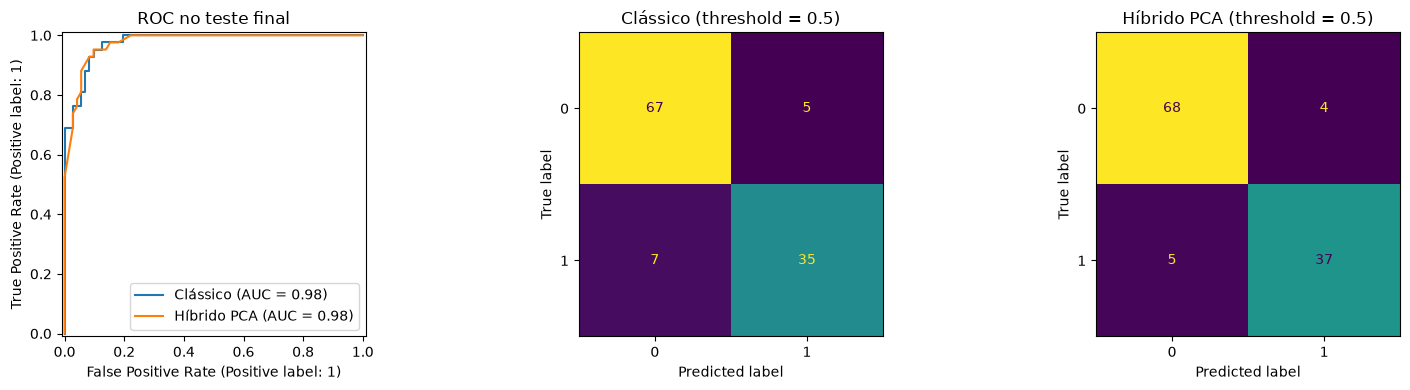

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

RocCurveDisplay.from_predictions(
    y_test,
    classical_probabilities,
    name="Clássico",
    ax=axes[0],
)
RocCurveDisplay.from_predictions(
    y_test,
    quantum_probabilities,
    name="Híbrido PCA",
    ax=axes[0],
)
axes[0].set_title("ROC no teste final")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    classical_predictions,
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title("Clássico (threshold = 0.5)")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    quantum_predictions,
    ax=axes[2],
    colorbar=False,
)
axes[2].set_title("Híbrido PCA (threshold = 0.5)")

plt.tight_layout()
plt.show()